In [1]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# 1. Exploración inicial
# Carga `iris_dataset.csv` con Pandas. Muestra las primeras 10 filas, las dimensiones del DataFrame, los
# nombres de las columnas y los tipos de datos. Identifica cuáles variables son numéricas y cuál es
# categórica.

datos_iris = pd.read_csv("../data/iris_dataset.csv")
datos_iris.head(10)

,sepal_length_cm,sepal_width_cm,petal_length_cm,petal_width_cm,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa
6,4.6,3.4,1.4,0.3,setosa
7,5.0,3.4,1.5,0.2,setosa
8,4.4,2.9,1.4,0.2,setosa
9,4.9,3.1,1.5,0.1,setosa


In [3]:
datos_iris.shape

(150, 5)

In [4]:
conteo_especies = datos_iris["species"].value_counts()
conteo_especies

species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

In [5]:
print(datos_iris.columns.to_list())

['sepal_length_cm', 'sepal_width_cm', 'petal_length_cm', 'petal_width_cm', 'species']


In [6]:
print(datos_iris.dtypes)

sepal_length_cm    float64
sepal_width_cm     float64
petal_length_cm    float64
petal_width_cm     float64
species             object
dtype: object


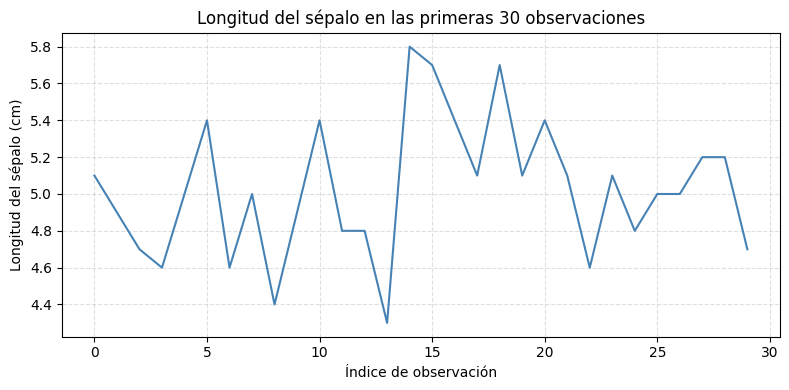

In [7]:
# 2. Línea: secuencia de observaciones
# Grafica con una línea la variable `sepal_length_cm` de las primeras 30 observaciones. Usa el índice de
# la fila como eje X. Agrega título y etiquetas a ambos ejes. Explica en una frase qué representa el orden
# en este caso.

primeras_30 = datos_iris.iloc[:30]

plt.figure(figsize=(8, 4))
plt.plot(primeras_30.index, primeras_30["sepal_length_cm"], color="steelblue")
plt.title("Longitud del sépalo en las primeras 30 observaciones")
plt.xlabel("Índice de observación")
plt.ylabel("Longitud del sépalo (cm)")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.show()

# El orden representa la posición de cada fila en el dataset, no una serie temporal.

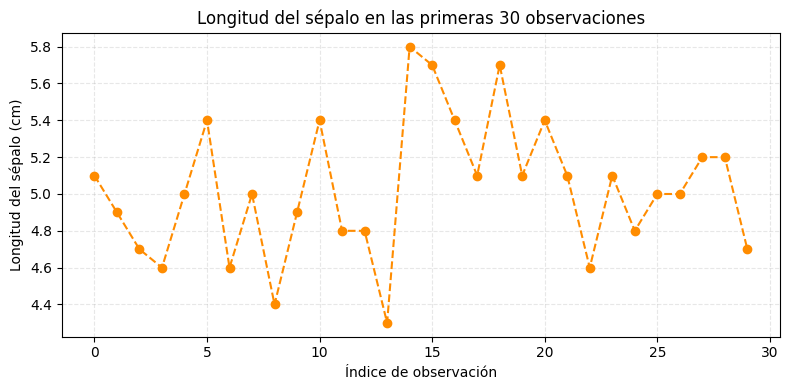

In [8]:
# 3. Línea: personalización
# Repite el gráfico anterior usando marcador circular, línea discontinua y un color diferente. Ajusta el
# tamaño de la figura y agrega una cuadrícula suave.

plt.figure(figsize=(8, 4))
plt.plot(
    primeras_30.index,
    primeras_30["sepal_length_cm"],
    marker="o",
    linestyle="--",
    color="darkorange",
)
plt.title("Longitud del sépalo en las primeras 30 observaciones")
plt.xlabel("Índice de observación")
plt.ylabel("Longitud del sépalo (cm)")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

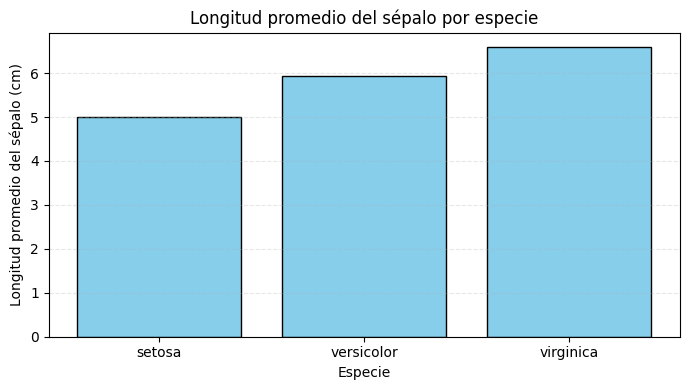

In [9]:
# 4. Barras: promedio por especie
# Calcula el promedio de `sepal_length_cm` para cada `species` y represéntalo con un gráfico de barras
# verticales. Incluye etiquetas de ejes y título.

promedio_sepalo = datos_iris.groupby("species")["sepal_length_cm"].mean()

plt.figure(figsize=(7, 4))
plt.bar(promedio_sepalo.index, promedio_sepalo.values, color="skyblue", edgecolor="black")
plt.title("Longitud promedio del sépalo por especie")
plt.xlabel("Especie")
plt.ylabel("Longitud promedio del sépalo (cm)")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

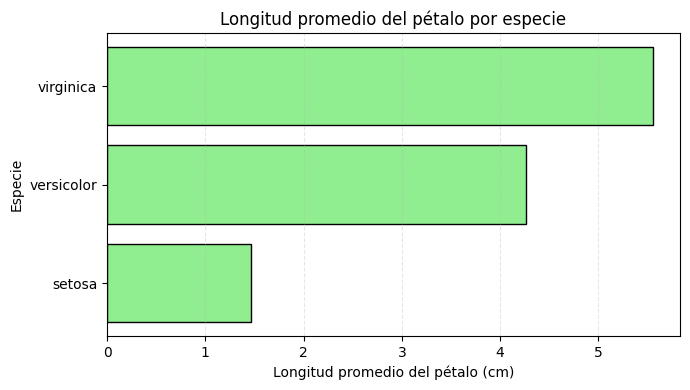

In [10]:
# 5. Barras horizontales
# Calcula el promedio de `petal_length_cm` por especie y crea un gráfico de barras horizontales. Ordena
# las especies de menor a mayor promedio antes de graficar.

promedio_petalo = datos_iris.groupby("species")["petal_length_cm"].mean().sort_values()

plt.figure(figsize=(7, 4))
plt.barh(promedio_petalo.index, promedio_petalo.values, color="lightgreen", edgecolor="black")
plt.title("Longitud promedio del pétalo por especie")
plt.xlabel("Longitud promedio del pétalo (cm)")
plt.ylabel("Especie")
plt.grid(True, axis="x", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

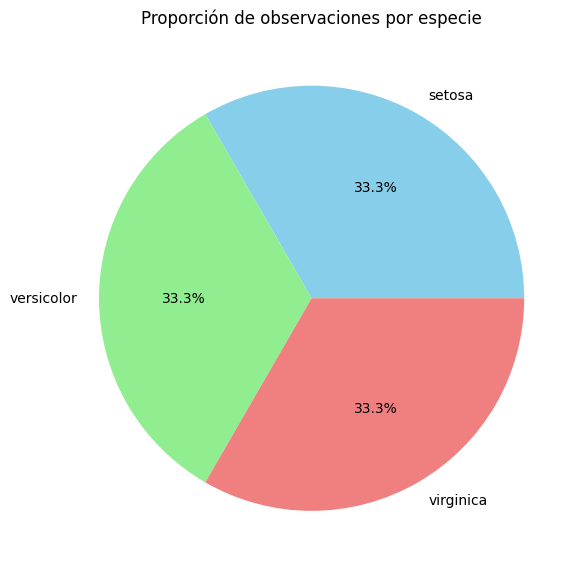

In [11]:
# 6. Pastel: composición del dataset
# Calcula cuántas observaciones existen por especie y represéntalas con un gráfico de pastel. Muestra los
# porcentajes con un decimal. ¿Qué conclusión obtienes sobre el balance del dataset?

conteo_especies = datos_iris["species"].value_counts()

plt.figure(figsize=(6, 6))
plt.pie(
    conteo_especies.values,
    labels=conteo_especies.index,
    autopct="%1.1f%%",
    colors=["skyblue", "lightgreen", "lightcoral"],
)
plt.title("Proporción de observaciones por especie")
plt.tight_layout()
plt.show()

# El dataset está balanceado: cada especie tiene el mismo número de observaciones.

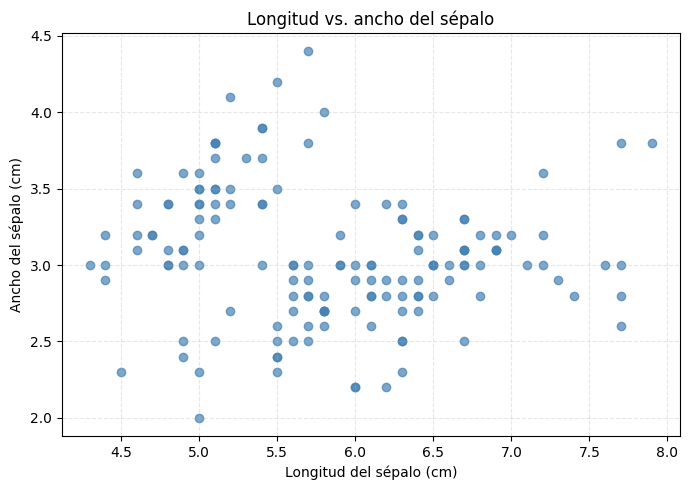

In [12]:
# 7. Dispersión: sépalo
# Crea un scatter plot entre `sepal_length_cm` y `sepal_width_cm`. Agrega título y etiquetas. Describe si
# visualmente parece existir una relación clara entre ambas variables.

plt.figure(figsize=(7, 5))
plt.scatter(
    datos_iris["sepal_length_cm"],
    datos_iris["sepal_width_cm"],
    color="steelblue",
    alpha=0.7,
)
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Ancho del sépalo (cm)")
plt.title("Longitud vs. ancho del sépalo")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Visualmente no se observa una relación lineal muy clara; los puntos están bastante dispersos.

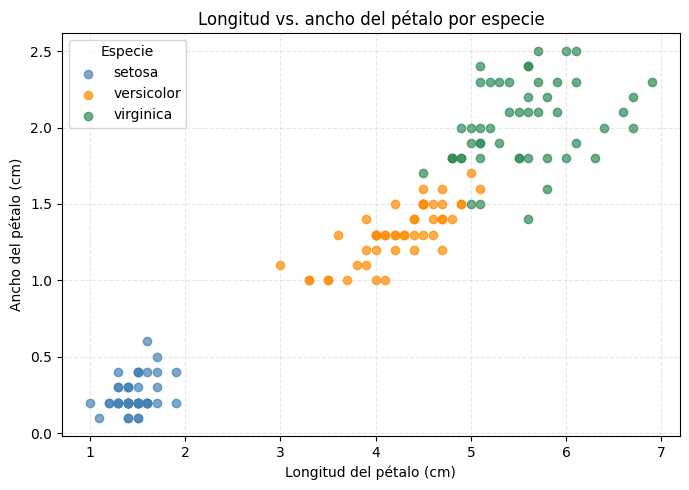

In [13]:
# 8. Dispersión por especie
# Crea un gráfico de dispersión entre `petal_length_cm` y `petal_width_cm`, diferenciando cada especie
# con una serie distinta y una leyenda. No uses Seaborn.

colores = ["steelblue", "darkorange", "seagreen"]

plt.figure(figsize=(7, 5))

for color, (especie, grupo) in zip(colores, datos_iris.groupby("species")):
    plt.scatter(
        grupo["petal_length_cm"],
        grupo["petal_width_cm"],
        label=especie,
        color=color,
        alpha=0.7,
    )

plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Ancho del pétalo (cm)")
plt.title("Longitud vs. ancho del pétalo por especie")
plt.legend(title="Especie")
plt.grid(True, linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

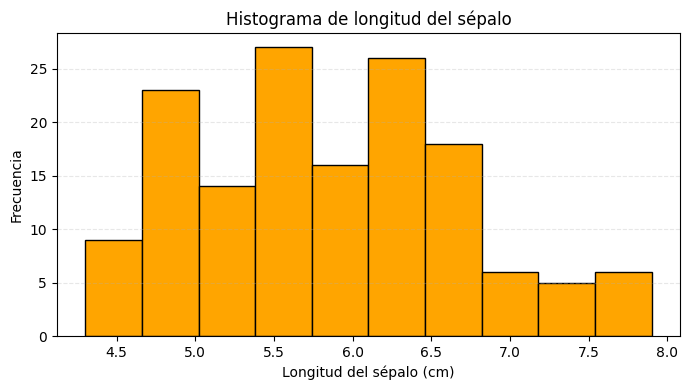

In [14]:
# 9. Histograma: longitud del sépalo
# Crea un histograma de `sepal_length_cm` con 10 bins, borde visible y etiquetas. Describe dónde se
# concentra la mayor parte de las observaciones.

plt.figure(figsize=(7, 4))
plt.hist(datos_iris["sepal_length_cm"], bins=10, color="orange", edgecolor="black")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Frecuencia")
plt.title("Histograma de longitud del sépalo")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# La mayoría de observaciones se concentra aproximadamente entre 5.0 y 6.5 cm.

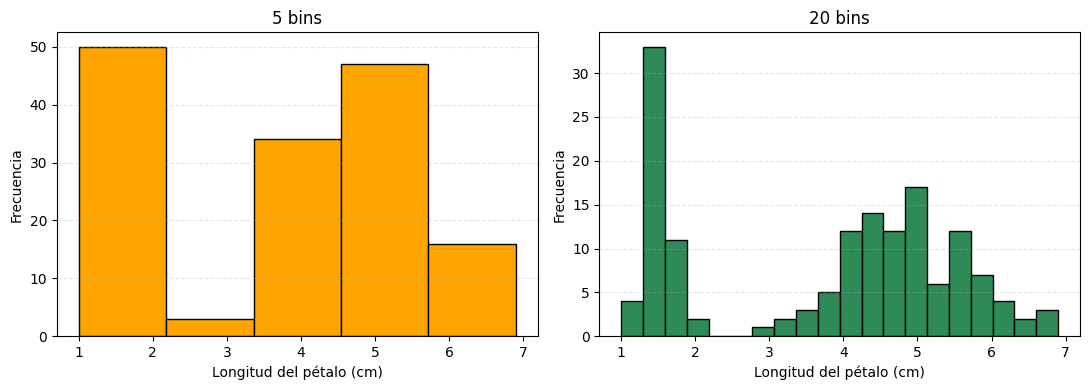

In [15]:
# 10. Histograma y bins
# Crea dos histogramas de `petal_length_cm`: uno con 5 bins y otro con 20 bins. Colócalos lado a lado
# usando subplots. Explica brevemente cómo cambia la interpretación al modificar los bins.

plt.figure(figsize=(11, 4))

plt.subplot(1, 2, 1)
plt.hist(datos_iris["petal_length_cm"], bins=5, color="orange", edgecolor="black")
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Frecuencia")
plt.title("5 bins")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(datos_iris["petal_length_cm"], bins=20, color="seagreen", edgecolor="black")
plt.xlabel("Longitud del pétalo (cm)")
plt.ylabel("Frecuencia")
plt.title("20 bins")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()

# Con 5 bins se ve una distribución más general; con 20 bins se aprecian mejor los detalles.

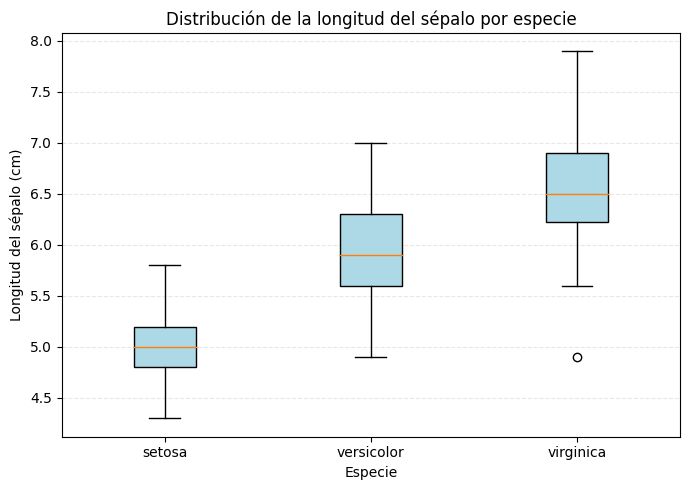

In [16]:
# 11. Boxplot por especie
# Construye un boxplot de `sepal_length_cm` separado por especie. Etiqueta cada caja con el nombre de
# su especie y compara visualmente las medianas.

datos_boxplot = []
etiquetas = []

for especie, grupo in datos_iris.groupby("species"):
    datos_boxplot.append(grupo["sepal_length_cm"])
    etiquetas.append(especie)

plt.figure(figsize=(7, 5))
plt.boxplot(datos_boxplot, patch_artist=True, boxprops={"facecolor": "lightblue"})
plt.xticks(range(1, len(etiquetas) + 1), etiquetas)
plt.xlabel("Especie")
plt.ylabel("Longitud del sépalo (cm)")
plt.title("Distribución de la longitud del sépalo por especie")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# Las medianas aumentan de setosa a versicolor y virginica.

In [17]:
# Verificación del número de grupos usados en el boxplot anterior.
numero_grupos = datos_iris["species"].nunique()
print(f"Número de grupos por especie: {numero_grupos}")

Número de grupos por especie: 3


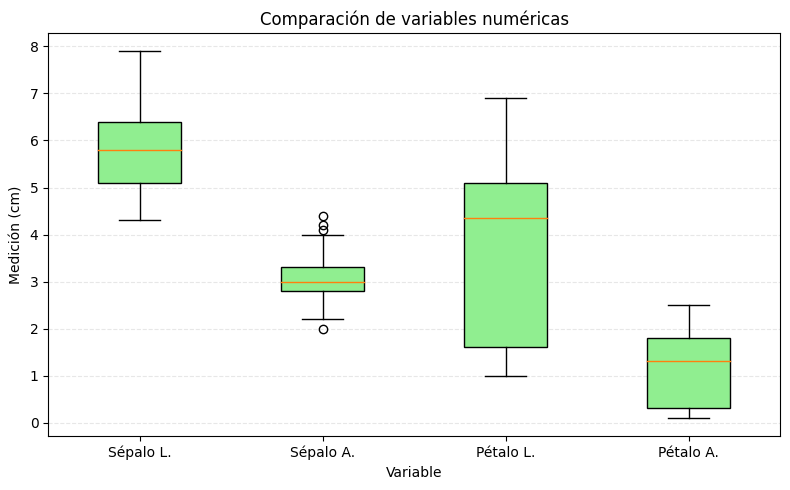

In [18]:
# 12. Boxplot de variables numéricas
# Crea un solo boxplot que compare las cuatro variables numéricas del dataset. Usa etiquetas cortas y
# legibles para cada caja. ¿Qué problema de escala observas?

columnas_numericas = datos_iris.select_dtypes("number").columns
datos_boxplot = [datos_iris[columna] for columna in columnas_numericas]
etiquetas = ["Sépalo L.", "Sépalo A.", "Pétalo L.", "Pétalo A."]

plt.figure(figsize=(8, 5))
plt.boxplot(datos_boxplot, patch_artist=True, boxprops={"facecolor": "lightgreen"})
plt.xticks(range(1, len(etiquetas) + 1), etiquetas)
plt.xlabel("Variable")
plt.ylabel("Medición (cm)")
plt.title("Comparación de variables numéricas")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)
plt.tight_layout()
plt.show()

# El problema de escala es que `petal_width_cm` tiene valores mucho menores que `sepal_length_cm`,
# por eso su caja se ve más comprimida.

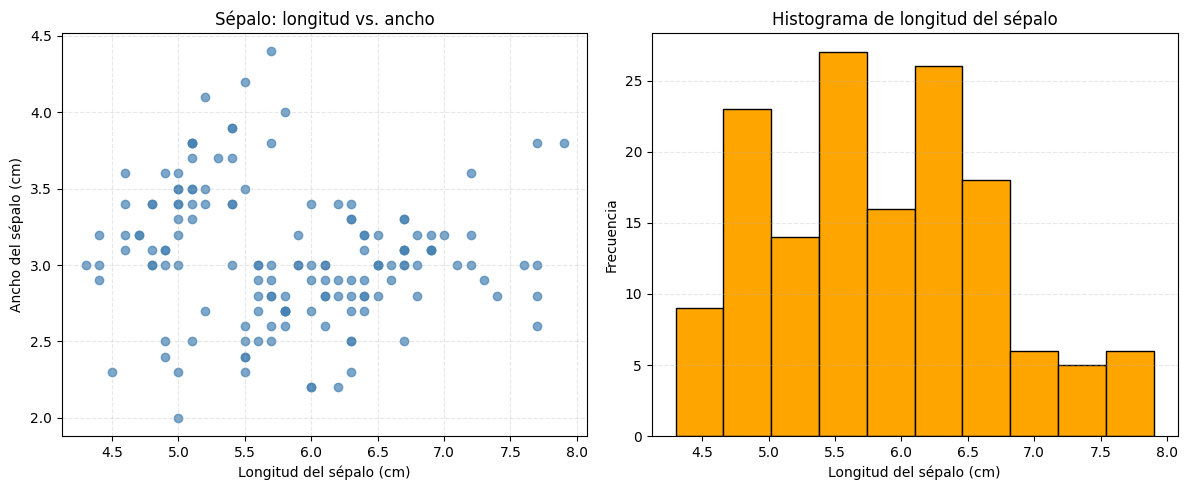

In [19]:
# 13. Subplots 1x2
# Crea una figura con dos subplots: a la izquierda un scatter de `sepal_length_cm` vs. `sepal_width_cm`; a
# la derecha un histograma de `sepal_length_cm`. Agrega un título independiente a cada panel.

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.scatter(
    datos_iris["sepal_length_cm"],
    datos_iris["sepal_width_cm"],
    color="steelblue",
    alpha=0.7,
)
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Ancho del sépalo (cm)")
plt.title("Sépalo: longitud vs. ancho")
plt.grid(True, linestyle="--", alpha=0.3)

plt.subplot(1, 2, 2)
plt.hist(datos_iris["sepal_length_cm"], bins=10, color="orange", edgecolor="black")
plt.xlabel("Longitud del sépalo (cm)")
plt.ylabel("Frecuencia")
plt.title("Histograma de longitud del sépalo")
plt.grid(True, axis="y", linestyle="--", alpha=0.3)

plt.tight_layout()
plt.show()